# Slum Area Prediction — All-Feature Model (Robust, Leakage-Free)

**Binary classification** of *Slum (1)* vs *Non-Slum (0)* per kelurahan across four
Indonesian cities (Ambon, DKI Jakarta, Kebumen, Samarinda) using **XGBoost** on the full
feature set: building footprint (Google Open Buildings) + Sentinel-2 optical + Sentinel-1 SAR.

This is a cleaned, corrected rewrite. Fixes applied:

1. **Honest headline metric.** PR-AUC is computed on **pooled out-of-fold (OOF)** predictions,
   not the selection-biased `RandomizedSearchCV.best_score_`.
2. **Consistent class weighting.** `scale_pos_weight` is recomputed **per training fold** and
   applied in every model (CV folds *and* the final model).
3. **No geographic leakage.** `city`, `unit_id`, and `unit_area_m2` are excluded from the
   features. `city` is used only as the spatial grouping variable.
4. **Leave-One-City-Out (LOCO)** validation — the model is always tested on a city it never saw.
5. **Imbalance-aware metrics**: PR-AUC + recall as headline (~14% prevalence), with a
   **per-city breakdown** so pooled numbers can't hide weak cities.
6. **Median imputation inside the pipeline** (fit per fold, no leakage).

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.model_selection import LeaveOneGroupOut, GroupKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (classification_report, confusion_matrix,
                             average_precision_score, roc_auc_score, roc_curve,
                             precision_recall_curve)
from xgboost import XGBClassifier
import shap

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
sns.set_theme(style='whitegrid')
PALETTE = {0: '#2ecc71', 1: '#e74c3c'}

## 2. Data Loading & Feature Definition (Anti-Leakage)

From the 38 columns we keep **34 predictive features**, grouped by data source. `slum` is the
target; `city` is the LOCO grouping variable; `unit_id` and `unit_area_m2` are metadata and are
**never** used as features (`unit_area_m2` is a geographic proxy and is already baked into the
density/coverage features).

In [2]:
df = pd.read_csv('../data/processed/features_buildings.csv')

META = ['slum', 'city', 'unit_id', 'unit_area_m2']

CORE_BUILDING = [
    'b_area_mean', 'b_area_median', 'b_area_std', 'b_area_sum',
    'b_count', 'b_coverage', 'b_density_km2', 'b_size_cv',
    'building_fractional_count_mean', 'building_fractional_count_stdDev',
    'building_height_mean', 'building_height_stdDev',
    'building_presence_mean', 'building_presence_stdDev',
]
NDBI_BUILTUP = [
    'ndbi_mean', 'ndbi_stdDev', 'ndbi_contrast_mean', 'ndbi_contrast_stdDev',
    'ndbi_ent_mean', 'ndbi_ent_stdDev', 'ndbi_var_mean', 'ndbi_var_stdDev',
]
SAR_SENTINEL1 = ['VH_mean', 'VH_stdDev', 'VV_mean', 'VV_stdDev', 'vv_vh_mean', 'vv_vh_stdDev']
OPTICAL_INDICES = ['brightness_mean', 'brightness_stdDev', 'bsi_mean', 'bsi_stdDev',
                   'ndvi_mean', 'ndvi_stdDev']

GROUPS = {
    'Building footprint (Google Open Buildings)': CORE_BUILDING,
    'NDBI built-up + texture (Sentinel-2)': NDBI_BUILTUP,
    'SAR radar (Sentinel-1)': SAR_SENTINEL1,
    'Optical indices (Sentinel-2)': OPTICAL_INDICES,
}

FEATURES = [c for c in (CORE_BUILDING + NDBI_BUILTUP + SAR_SENTINEL1 + OPTICAL_INDICES)
            if c in df.columns]
feat_group = {f: g for g, cols in GROUPS.items() for f in cols}

y = df['slum'].astype(int).values
groups = df['city'].values

overview = pd.DataFrame({
    'group': list(GROUPS.keys()) + ['TOTAL'],
    'n_features': [len([c for c in cols if c in df.columns]) for cols in GROUPS.values()]
                  + [len(FEATURES)],
})
display(overview)
display(pd.Series({
    'n_samples': len(y), 'n_slum': int(y.sum()),
    'prevalence': round(float(y.mean()), 4), 'n_cities': int(len(np.unique(groups))),
}).to_frame('value'))

,group,n_features
0,Building footprint (Google Open Buildings),14
1,NDBI built-up + texture (Sentinel-2),8
2,SAR radar (Sentinel-1),6
3,Optical indices (Sentinel-2),6
4,TOTAL,34


,value
n_samples,828.0000
n_slum,118.0000
prevalence,0.1425
n_cities,4.0000


## 3. Exploratory Data Analysis

We examine (a) class balance and how prevalence varies by city, (b) which features correlate
with slums and which data source they come from, (c) multicollinearity, (d) class-conditional
distributions of the strongest features, (e) the spectral space, and (f) cross-city
distribution shift — the key motivation for LOCO validation.

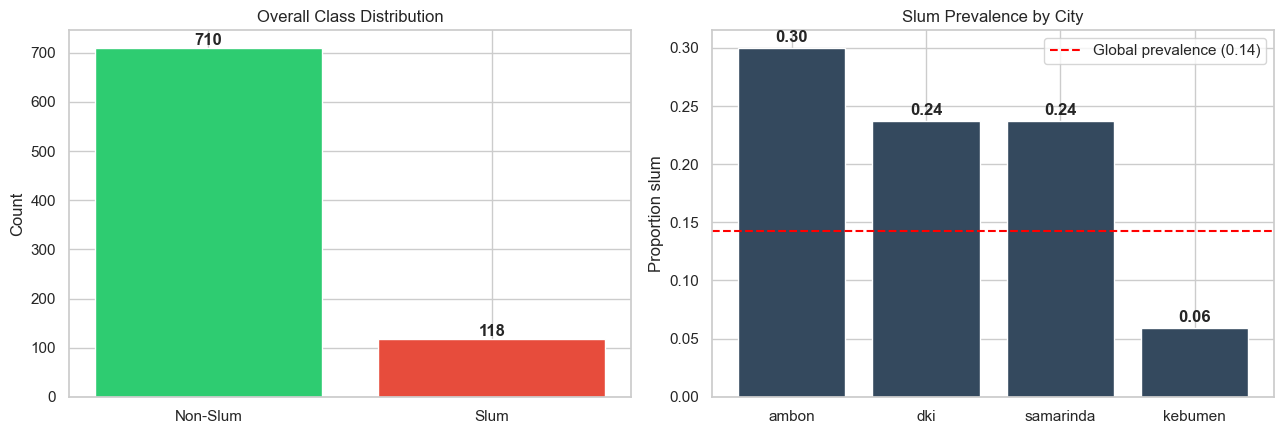

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

counts = pd.Series(y).map({0: 'Non-Slum', 1: 'Slum'}).value_counts()
ax[0].bar(counts.index, counts.values, color=[PALETTE[0], PALETTE[1]])
for i, v in enumerate(counts.values):
    ax[0].text(i, v + 5, str(v), ha='center', fontweight='bold')
ax[0].set_title('Overall Class Distribution')
ax[0].set_ylabel('Count')

prev = df.groupby('city')['slum'].mean().sort_values(ascending=False)
ax[1].bar(prev.index, prev.values, color='#34495e')
ax[1].axhline(y.mean(), ls='--', color='red', label=f'Global prevalence ({y.mean():.2f})')
for i, v in enumerate(prev.values):
    ax[1].text(i, v + 0.005, f'{v:.2f}', ha='center', fontweight='bold')
ax[1].set_title('Slum Prevalence by City')
ax[1].set_ylabel('Proportion slum')
ax[1].legend()
plt.tight_layout()
plt.show()

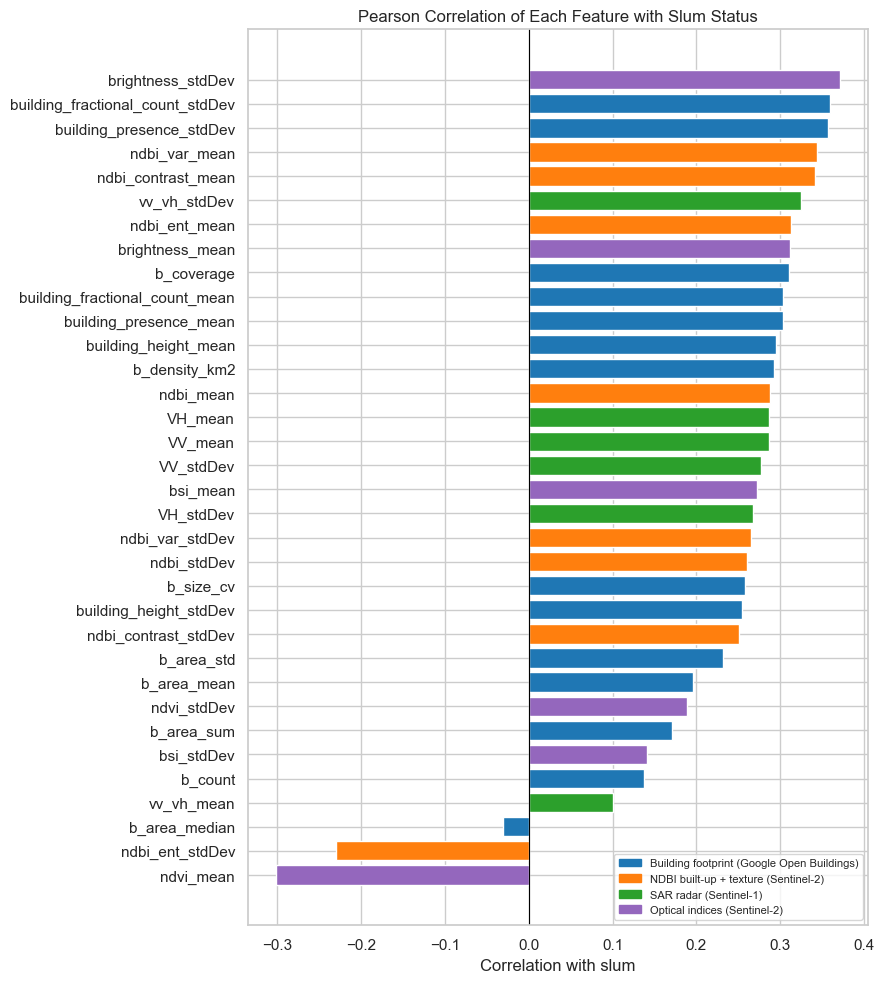

In [4]:
corr = df[FEATURES + ['slum']].corr()['slum'].drop('slum').sort_values()
colors_map = {
    'Building footprint (Google Open Buildings)': '#1f77b4',
    'NDBI built-up + texture (Sentinel-2)': '#ff7f0e',
    'SAR radar (Sentinel-1)': '#2ca02c',
    'Optical indices (Sentinel-2)': '#9467bd',
}
bar_colors = [colors_map[feat_group[f]] for f in corr.index]

plt.figure(figsize=(9, 10))
plt.barh(corr.index, corr.values, color=bar_colors)
plt.axvline(0, color='black', lw=0.8)
plt.title('Pearson Correlation of Each Feature with Slum Status')
plt.xlabel('Correlation with slum')
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in colors_map.values()]
plt.legend(handles, colors_map.keys(), loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

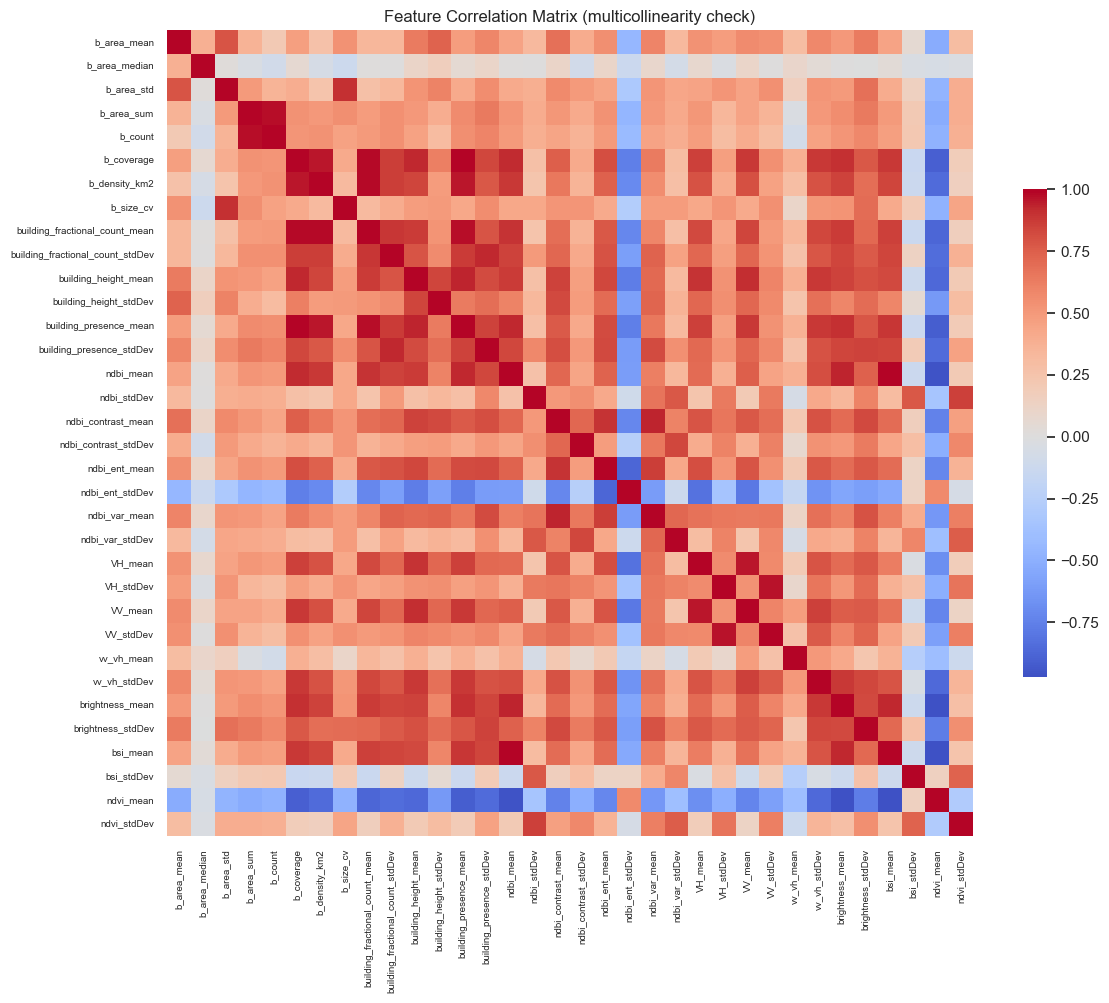

In [5]:
plt.figure(figsize=(12, 10))
sns.heatmap(df[FEATURES].corr(), cmap='coolwarm', center=0, square=True,
            cbar_kws={'shrink': 0.6}, xticklabels=True, yticklabels=True)
plt.title('Feature Correlation Matrix (multicollinearity check)')
plt.xticks(fontsize=7, rotation=90)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()

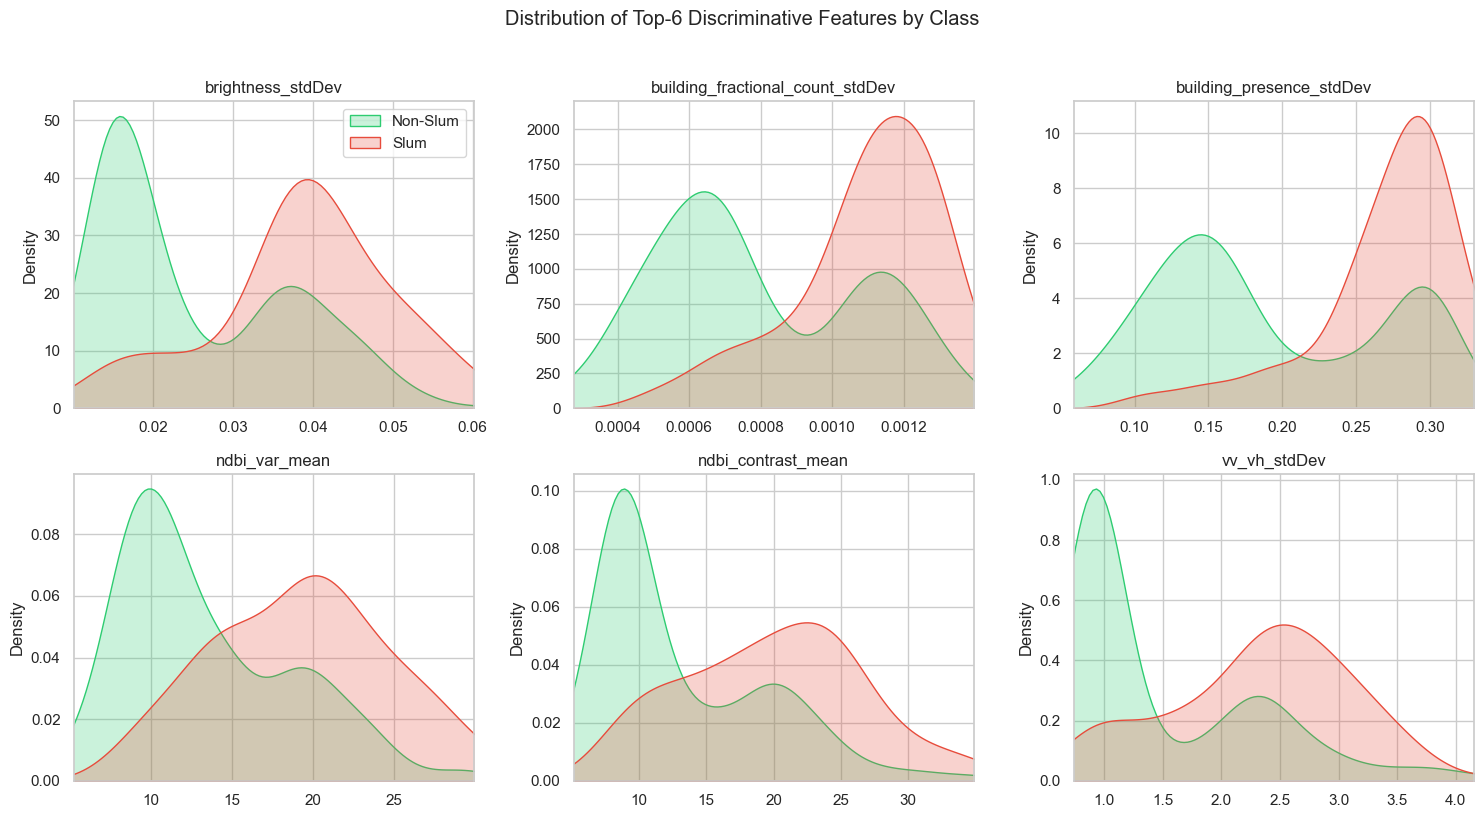

In [6]:
top_feats = corr.abs().sort_values(ascending=False).head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for axi, f in zip(axes.ravel(), top_feats):
    for cls in [0, 1]:
        sns.kdeplot(df.loc[df['slum'] == cls, f], ax=axi, fill=True,
                    color=PALETTE[cls], common_norm=False,
                    label=('Slum' if cls else 'Non-Slum'))
    axi.set_title(f)
    axi.set_xlabel('')
    axi.set_xlim(df[f].quantile(0.01), df[f].quantile(0.99))
axes.ravel()[0].legend()
fig.suptitle('Distribution of Top-6 Discriminative Features by Class', y=1.02)
plt.tight_layout()
plt.show()

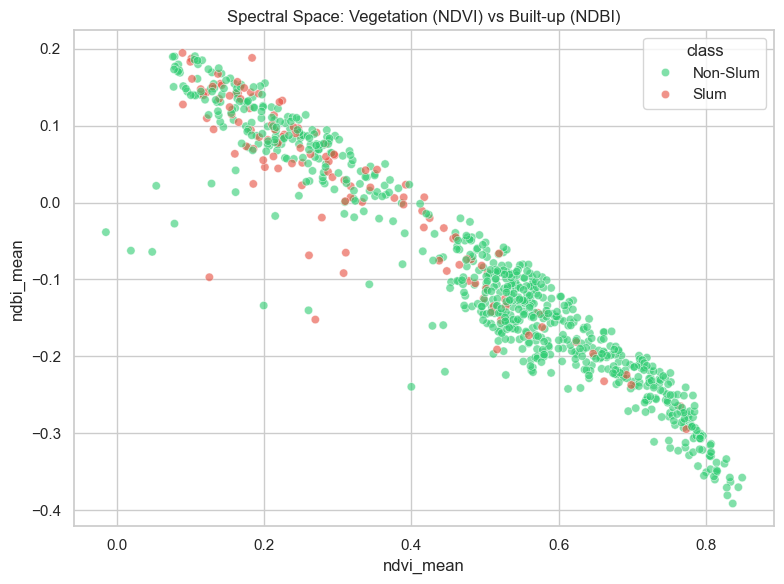

In [7]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='ndvi_mean', y='ndbi_mean', hue='slum', alpha=0.6, palette=PALETTE)
plt.title('Spectral Space: Vegetation (NDVI) vs Built-up (NDBI)')
handles, _ = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['Non-Slum', 'Slum'], title='class')
plt.tight_layout()
plt.show()

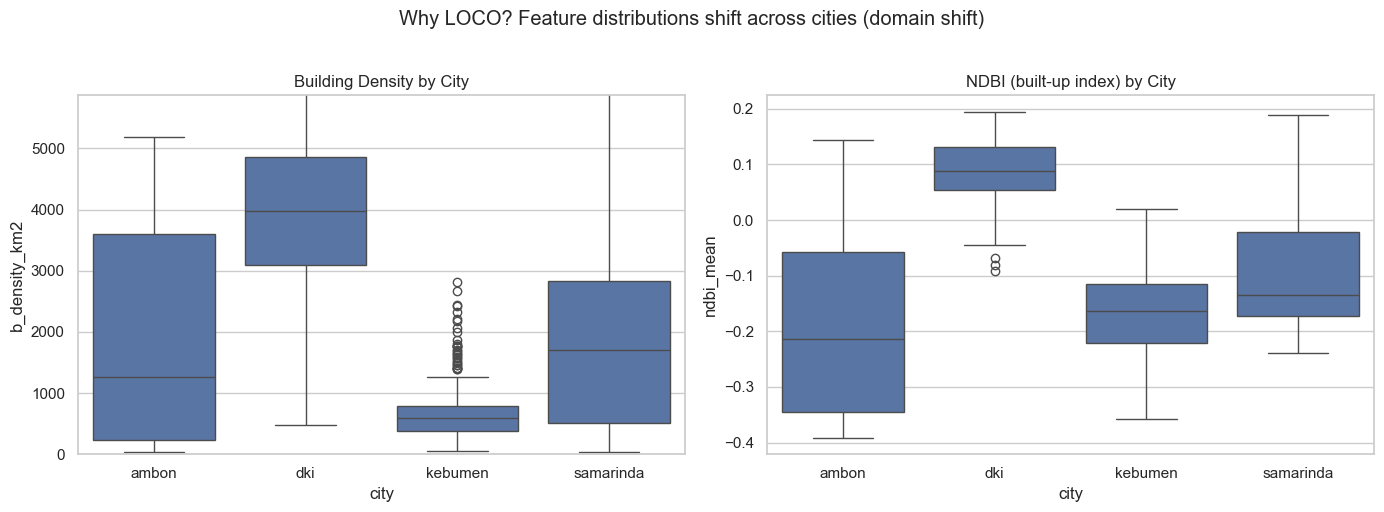

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='city', y='b_density_km2', ax=ax[0])
ax[0].set_ylim(0, df['b_density_km2'].quantile(0.97))
ax[0].set_title('Building Density by City')
sns.boxplot(data=df, x='city', y='ndbi_mean', ax=ax[1])
ax[1].set_title('NDBI (built-up index) by City')
fig.suptitle('Why LOCO? Feature distributions shift across cities (domain shift)', y=1.02)
plt.tight_layout()
plt.show()

## 4. Validation Strategy: Leave-One-City-Out (LOCO)

With only ~828 rows and 4 cities, a random split puts near-identical neighbouring kelurahan in
both train and test (spatial autocorrelation), inflating scores. LOCO trains on 3 cities and
tests on the 4th — forcing the model to generalise to an **unseen city**, exactly the real
deployment condition. The table below shows each fold's composition.

In [9]:
rows = []
for tr, te in LeaveOneGroupOut().split(np.zeros(len(y)), y, groups):
    rows.append({
        'test_city': groups[te][0],
        'train_cities': ', '.join(sorted(np.unique(groups[tr]))),
        'n_train': len(tr), 'slum_train': int(y[tr].sum()),
        'n_test': len(te), 'slum_test': int(y[te].sum()),
    })
pd.DataFrame(rows)

,test_city,train_cities,n_train,slum_train,n_test,slum_test
0,ambon,"dki, kebumen, samarinda",778,103,50,15
1,dki,"ambon, kebumen, samarinda",567,56,261,62
2,kebumen,"ambon, dki, samarinda",370,91,458,27
3,samarinda,"ambon, dki, kebumen",769,104,59,14


## 5. Model & Honest LOCO Out-of-Fold Prediction

A simple pipeline: median imputation followed by XGBoost (trees are scale-invariant, so no
scaler). Parameters are pre-registered and deliberately conservative for a small dataset.
`scale_pos_weight` is recomputed from the **training fold only** to avoid leaking the test
city's prevalence.

In [10]:
def make_xgb(scale_pos_weight, **params):
    cfg = dict(
        n_estimators=400, max_depth=3, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=2.0, min_child_weight=2,
        scale_pos_weight=scale_pos_weight, objective='binary:logistic',
        eval_metric='aucpr', n_jobs=-1, random_state=RANDOM_STATE, verbosity=0,
    )
    cfg.update(params)
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('clf', XGBClassifier(**cfg)),
    ])

def loco_oof(feature_cols, params=None):
    # Pooled OOF probabilities: each city is predicted only by a model trained on the
    # other three cities. scale_pos_weight is recomputed per fold (train-only).
    params = params or {}
    X = df[feature_cols]
    oof = np.zeros(len(y))
    for tr, te in LeaveOneGroupOut().split(X, y, groups):
        spw = (y[tr] == 0).sum() / max((y[tr] == 1).sum(), 1)
        model = make_xgb(spw, **params).fit(X.iloc[tr], y[tr])
        oof[te] = model.predict_proba(X.iloc[te])[:, 1]
    return oof

def per_city_metrics(oof):
    out = []
    for c in sorted(np.unique(groups)):
        m = groups == c
        out.append({
            'city': c, 'n': int(m.sum()), 'slum': int(y[m].sum()),
            'PR_AUC': average_precision_score(y[m], oof[m]),
            'ROC_AUC': roc_auc_score(y[m], oof[m]),
        })
    return pd.DataFrame(out)

oof = loco_oof(FEATURES)

## 6. Headline Metrics (Honest, Cross-City)

PR-AUC on pooled OOF predictions is the trustworthy headline. The per-city table shows that
pooled performance hides large variation — some cities are near-random.

In [11]:
pr_auc = average_precision_score(y, oof)
roc_auc = roc_auc_score(y, oof)
baseline = float(y.mean())

display(pd.DataFrame({
    'metric': ['PR-AUC (LOCO OOF)', 'ROC-AUC (LOCO OOF)',
               'Baseline PR-AUC (prevalence)', 'Lift over baseline (x)'],
    'value': [round(pr_auc, 4), round(roc_auc, 4),
              round(baseline, 4), round(pr_auc / baseline, 2)],
}))
per_city_metrics(oof).round(3)

,metric,value
0,PR-AUC (LOCO OOF),0.2565
1,ROC-AUC (LOCO OOF),0.7410
2,Baseline PR-AUC (prevalence),0.1425
3,Lift over baseline (x),1.8000


,city,n,slum,PR_AUC,ROC_AUC
0,ambon,50,15,0.645,0.851
1,dki,261,62,0.251,0.498
2,kebumen,458,27,0.470,0.773
3,samarinda,59,14,0.437,0.727


## 7. Threshold Optimization & Classification Report

The decision threshold maximises F1 on the OOF predictions. This makes the F1/threshold
*slightly optimistic* (tuned on the same predictions); the threshold-free PR-AUC above remains
the trustworthy headline.

In [12]:
prec, rec, thr = precision_recall_curve(y, oof)
f1 = 2 * prec * rec / (prec + rec + 1e-12)
best = int(np.nanargmax(f1[:-1]))
best_threshold = float(thr[best])
y_pred = (oof >= best_threshold).astype(int)

display(pd.Series({'optimal_F1_threshold': round(best_threshold, 3),
                   'max_F1_OOF': round(float(f1[best]), 3)}).to_frame('value'))
pd.DataFrame(classification_report(
    y, y_pred, target_names=['Non-Slum', 'Slum'], output_dict=True)).T.round(3)

,value
optimal_F1_threshold,0.113
max_F1_OOF,0.429


,precision,recall,f1-score,support
Non-Slum,0.957,0.666,0.786,710.000
Slum,0.290,0.822,0.429,118.000
accuracy,0.688,0.688,0.688,0.688
macro avg,0.624,0.744,0.607,828.000
weighted avg,0.862,0.688,0.735,828.000


## 8. Evaluation Plots

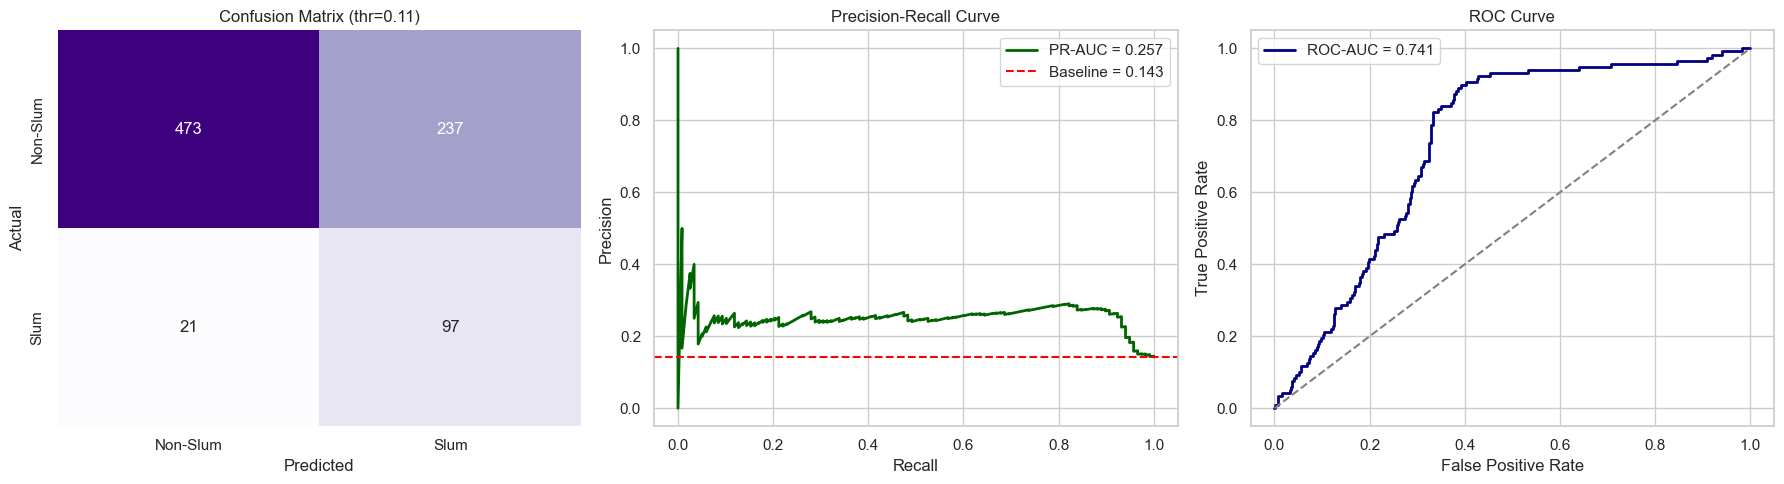

In [13]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', cbar=False,
            xticklabels=['Non-Slum', 'Slum'], yticklabels=['Non-Slum', 'Slum'], ax=ax[0])
ax[0].set_title(f'Confusion Matrix (thr={best_threshold:.2f})')
ax[0].set_xlabel('Predicted'); ax[0].set_ylabel('Actual')

ax[1].plot(rec, prec, color='darkgreen', lw=2, label=f'PR-AUC = {pr_auc:.3f}')
ax[1].axhline(baseline, ls='--', color='red', label=f'Baseline = {baseline:.3f}')
ax[1].set_xlabel('Recall'); ax[1].set_ylabel('Precision')
ax[1].set_title('Precision-Recall Curve'); ax[1].legend()

fpr, tpr, _ = roc_curve(y, oof)
ax[2].plot(fpr, tpr, color='navy', lw=2, label=f'ROC-AUC = {roc_auc:.3f}')
ax[2].plot([0, 1], [0, 1], ls='--', color='grey')
ax[2].set_xlabel('False Positive Rate'); ax[2].set_ylabel('True Positive Rate')
ax[2].set_title('ROC Curve'); ax[2].legend()

plt.tight_layout()
plt.show()

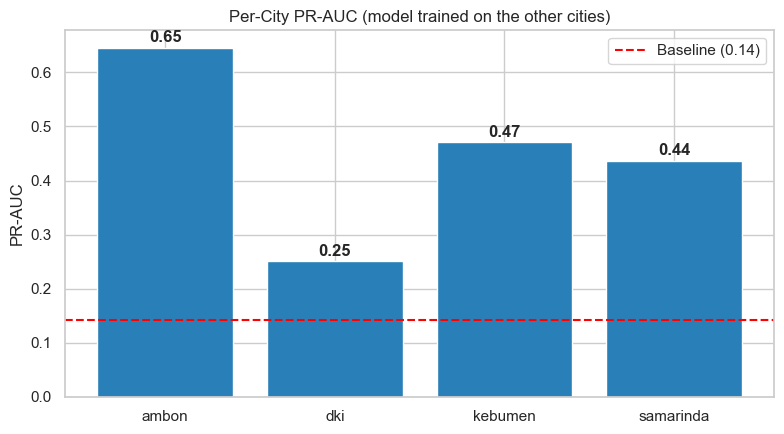

In [14]:
pc = per_city_metrics(oof)
plt.figure(figsize=(8, 4.5))
plt.bar(pc['city'], pc['PR_AUC'], color='#2980b9')
plt.axhline(baseline, ls='--', color='red', label=f'Baseline ({baseline:.2f})')
for i, v in enumerate(pc['PR_AUC']):
    plt.text(i, v + 0.01, f'{v:.2f}', ha='center', fontweight='bold')
plt.title('Per-City PR-AUC (model trained on the other cities)')
plt.ylabel('PR-AUC'); plt.legend()
plt.tight_layout()
plt.show()

## 9. Feature Importance (SHAP)

The final model is trained on all data (global `scale_pos_weight`) for interpretation only.
SHAP shows which features drive slum predictions across all data sources.

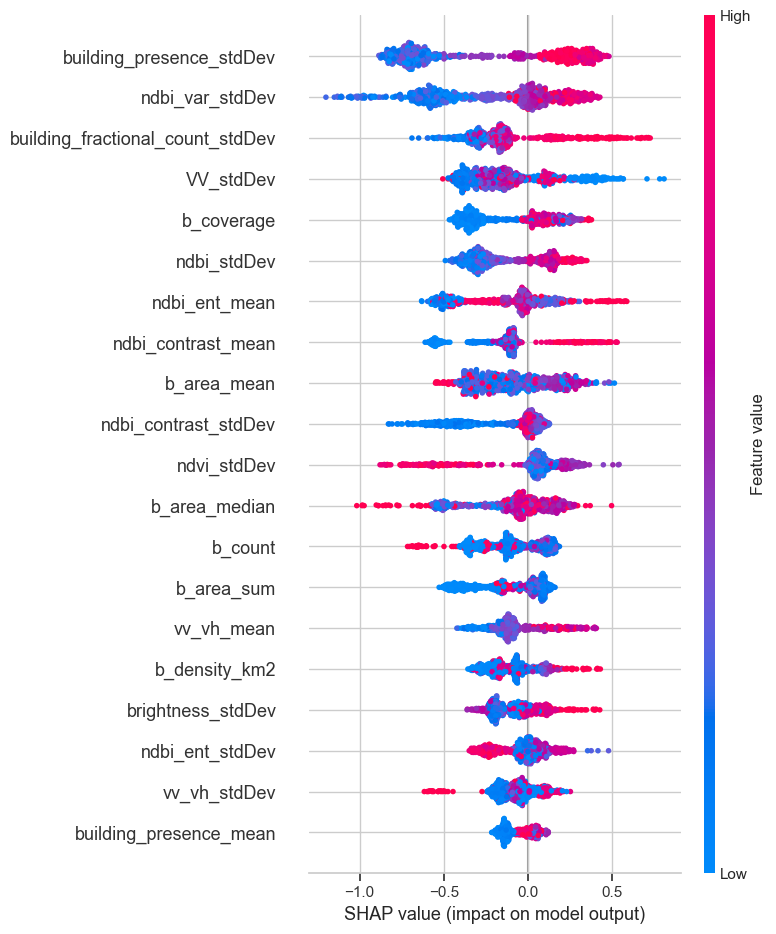

In [15]:
spw_all = (y == 0).sum() / (y == 1).sum()
final_model = make_xgb(spw_all).fit(df[FEATURES], y)

clf = final_model.named_steps['clf']
X_imputed = pd.DataFrame(final_model.named_steps['imputer'].transform(df[FEATURES]),
                         columns=FEATURES)
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_imputed)
shap.summary_plot(shap_values, X_imputed, max_display=20)

## 10. Does Adding Spectral/Radar Features Help? (Honest Ablation)

Compare building-footprint-only (14) vs the full feature set (34) on the **same** honest LOCO
OOF metric. On a dataset this small, fusing extra spectral/radar sources often adds only
noise-level gains.

In [16]:
oof_building = loco_oof(CORE_BUILDING)
ablation = pd.DataFrame([
    {'feature_set': 'Building footprint only', 'n_features': len(CORE_BUILDING),
     'PR_AUC': average_precision_score(y, oof_building),
     'ROC_AUC': roc_auc_score(y, oof_building)},
    {'feature_set': 'All features (fusion)', 'n_features': len(FEATURES),
     'PR_AUC': pr_auc, 'ROC_AUC': roc_auc},
]).round(4)
ablation['PR_AUC_gain'] = (ablation['PR_AUC'] - ablation['PR_AUC'].iloc[0]).round(4)
ablation

,feature_set,n_features,PR_AUC,ROC_AUC,PR_AUC_gain
0,Building footprint only,14,0.2555,0.7441,0.000
1,All features (fusion),34,0.2565,0.7410,0.001


## 11. Optional: Does Hyperparameter Tuning Help? (Nested LOCO)

The previous notebook reported `RandomizedSearchCV.best_score_` (~0.45), which is
**selection-biased** — it is the best of many candidates measured on the same folds, and it
averages per-fold AP rather than pooling. Proper **nested** CV tunes inside each training split
and tests on the held-out city. It is slower and usually does *not* beat sensible fixed params
on a dataset this small. (Run this cell only if you want the comparison.)

In [17]:
param_dist = {
    'clf__n_estimators': [200, 300, 400],
    'clf__max_depth': [2, 3, 4],
    'clf__learning_rate': [0.01, 0.03, 0.05],
    'clf__subsample': [0.7, 0.8, 0.9],
    'clf__colsample_bytree': [0.6, 0.8, 1.0],
}

def nested_loco_oof(feature_cols, n_iter=12):
    X = df[feature_cols]
    oof_t = np.zeros(len(y))
    for tr, te in LeaveOneGroupOut().split(X, y, groups):
        spw = (y[tr] == 0).sum() / max((y[tr] == 1).sum(), 1)
        search = RandomizedSearchCV(
            make_xgb(spw), param_dist, n_iter=n_iter, scoring='average_precision',
            cv=GroupKFold(n_splits=3), random_state=RANDOM_STATE, n_jobs=-1,
        )
        search.fit(X.iloc[tr], y[tr], groups=groups[tr])
        oof_t[te] = search.best_estimator_.predict_proba(X.iloc[te])[:, 1]
    return oof_t

oof_tuned = nested_loco_oof(FEATURES)
pd.DataFrame({
    'approach': ['Fixed params (Section 6)', 'Nested-CV tuned'],
    'PR_AUC': [round(pr_auc, 4), round(average_precision_score(y, oof_tuned), 4)],
    'ROC_AUC': [round(roc_auc, 4), round(roc_auc_score(y, oof_tuned), 4)],
})

,approach,PR_AUC,ROC_AUC
0,Fixed params (Section 6),0.2565,0.741
1,Nested-CV tuned,0.2724,0.741


## 12. Inference on a New Area

`predict_new_area` scores any dataframe with the same feature columns. For an honest estimate
of new-city performance, feed data from a city **not** used in training. The demo below scores
in-sample rows for illustration only (so its numbers are optimistic).

In [18]:
def predict_new_area(df_new, model=final_model, features=FEATURES, threshold=best_threshold):
    proba = model.predict_proba(df_new[features])[:, 1]
    out = df_new.copy()
    out['slum_probability'] = proba
    out['slum_prediction'] = (proba >= threshold).astype(int)
    return out

demo = predict_new_area(df.sample(5, random_state=10))
demo[['unit_id', 'city', 'slum', 'slum_probability', 'slum_prediction']]

,unit_id,city,slum,slum_probability,slum_prediction
339,kebumen_0028,kebumen,0,0.028754,0
68,dki_0018,dki,0,0.257019,1
264,dki_0214,dki,0,0.266105,1
278,dki_0228,dki,0,0.291186,1
529,kebumen_0218,kebumen,1,0.887415,1
